<a href="https://colab.research.google.com/github/anamitra-tech/ML-Projects/blob/main/World_stock_price_predictions_usingXGBOOST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
!git clone https://github.com/anamitra-tech/ML-projects.git


Cloning into 'ML-projects'...
fatal: could not read Username for 'https://github.com': No such device or address


/tmp/ipython-input-2748482554.py:13: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["Date"] = pd.to_datetime(df["Date"])
/tmp/ipython-input-2748482554.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Ticker", group_keys=False).apply(create_features)


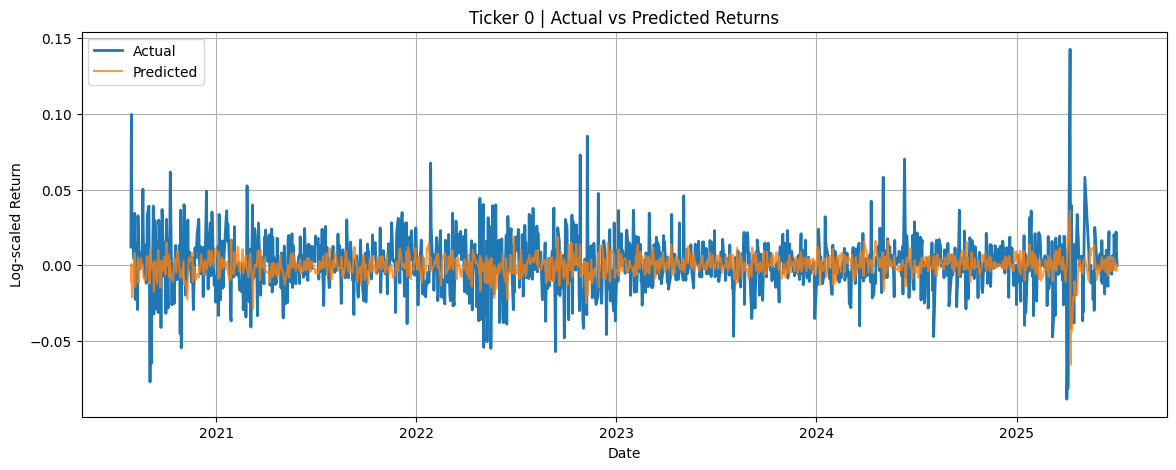

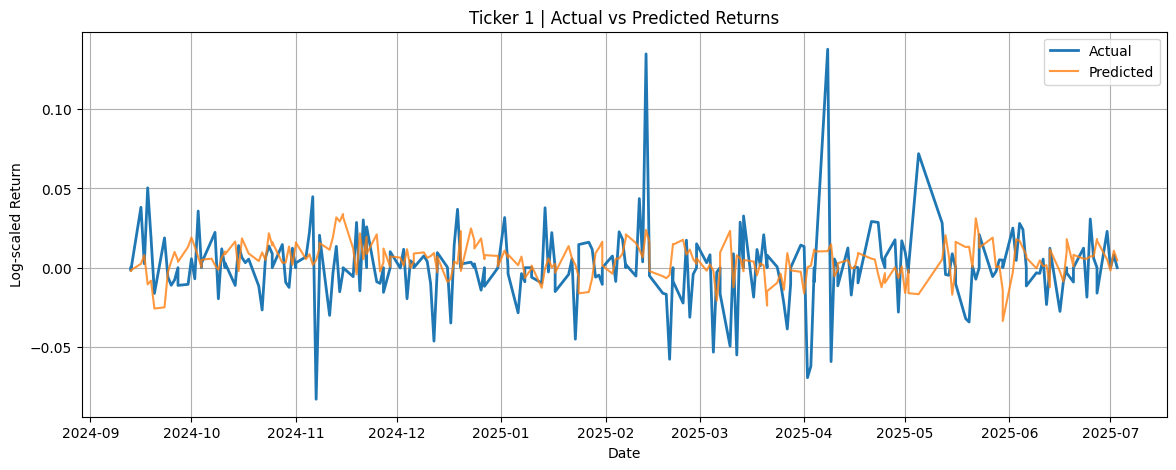

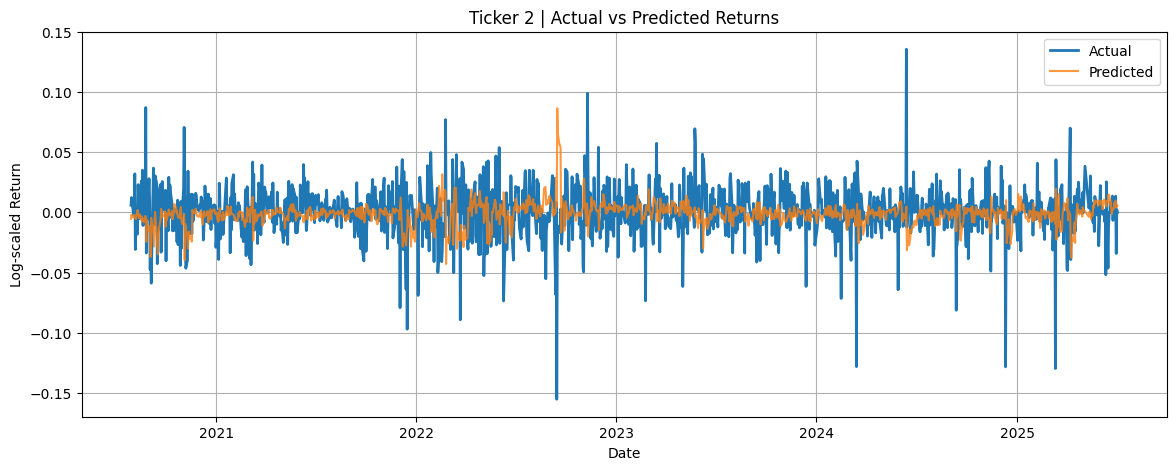

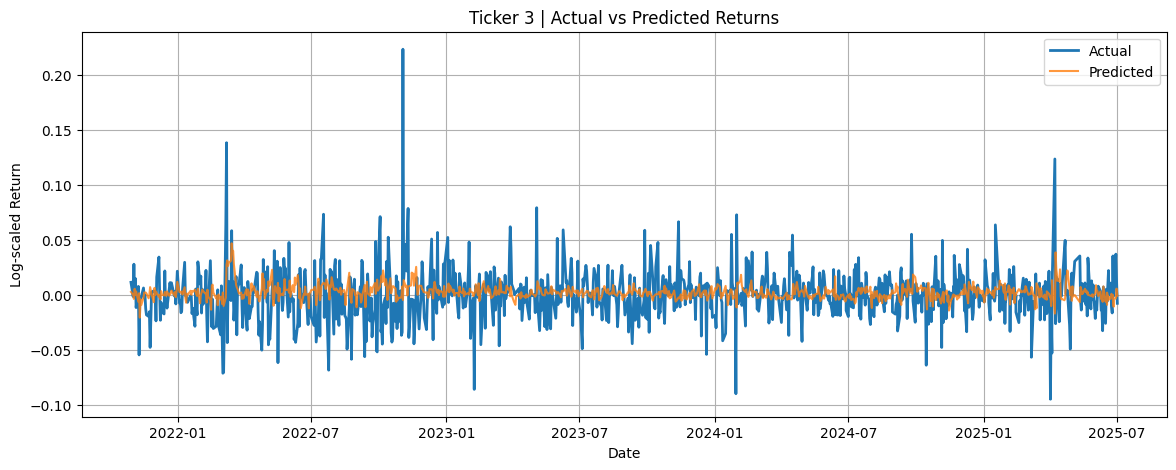

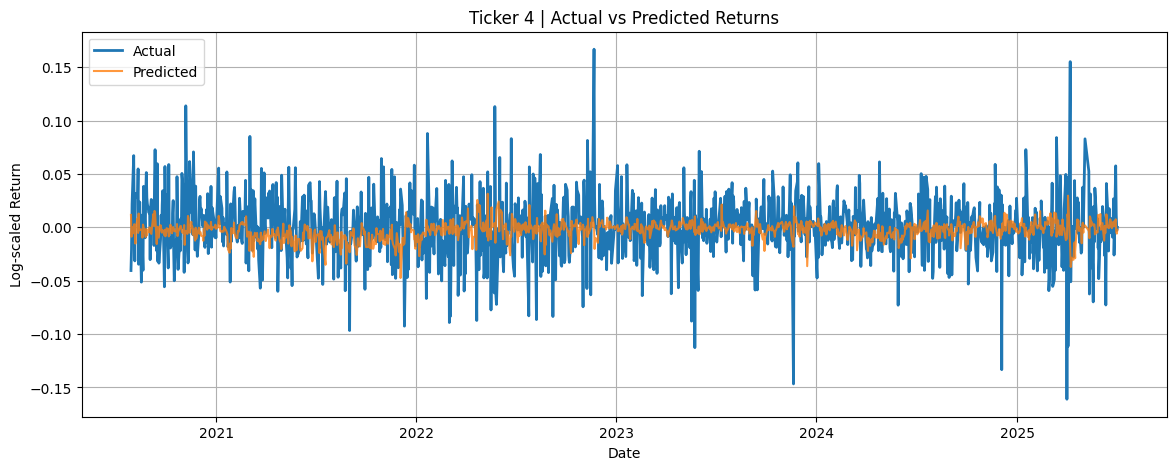

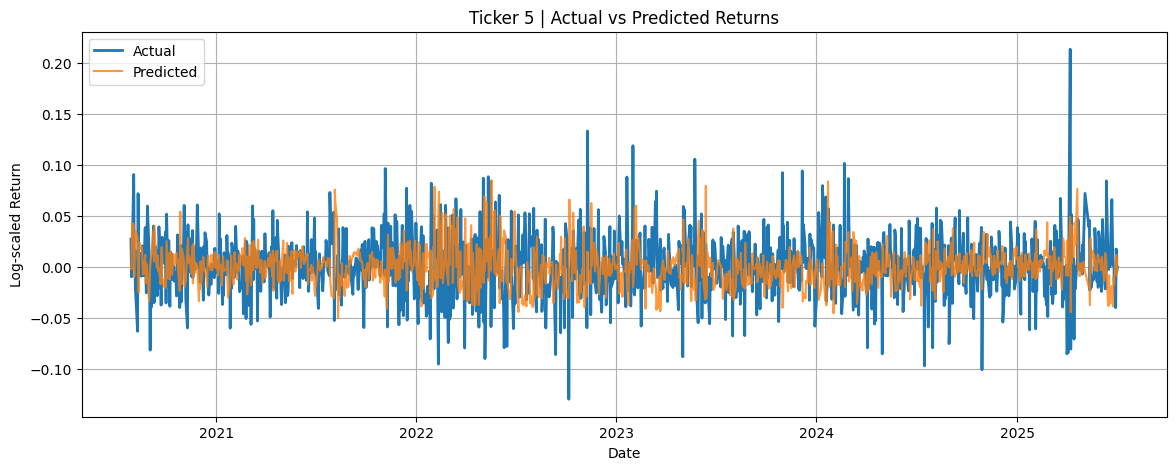

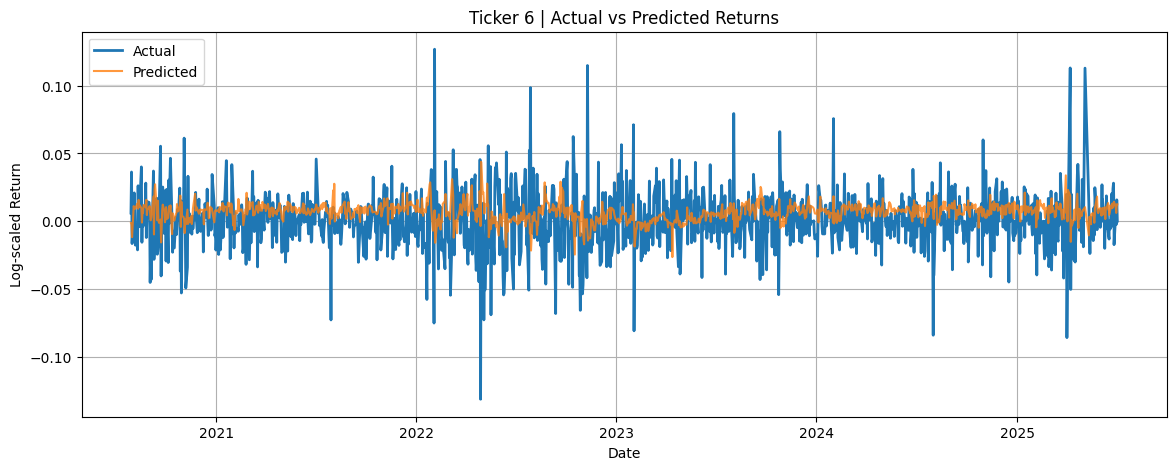

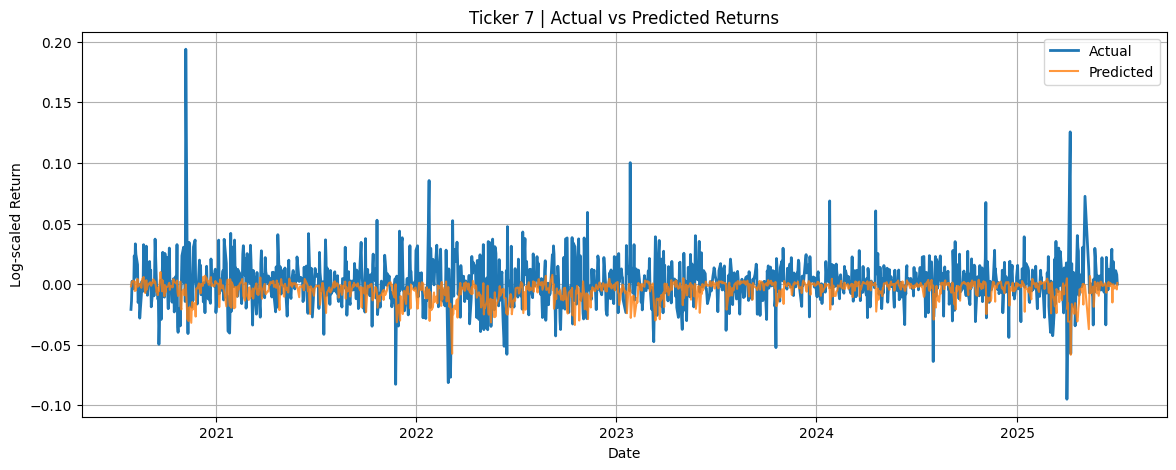

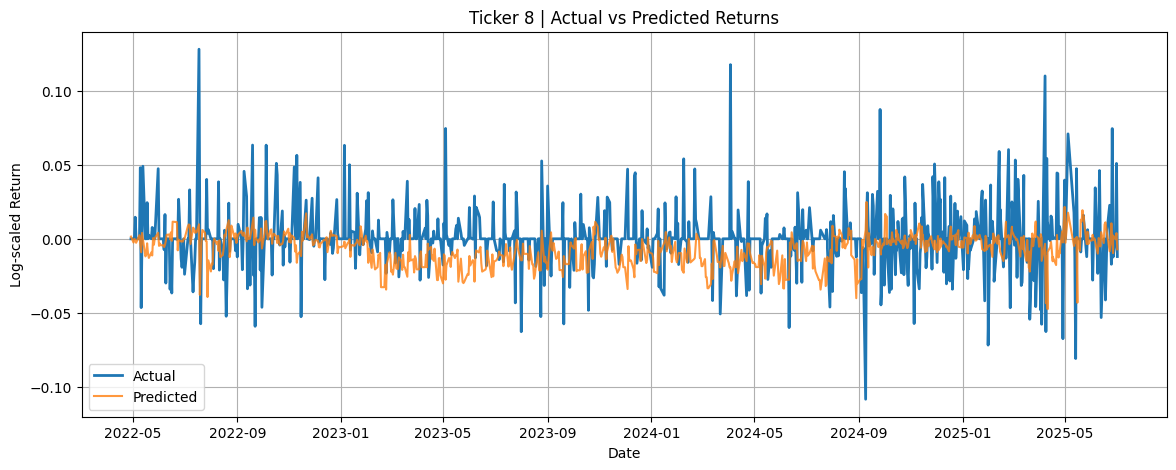

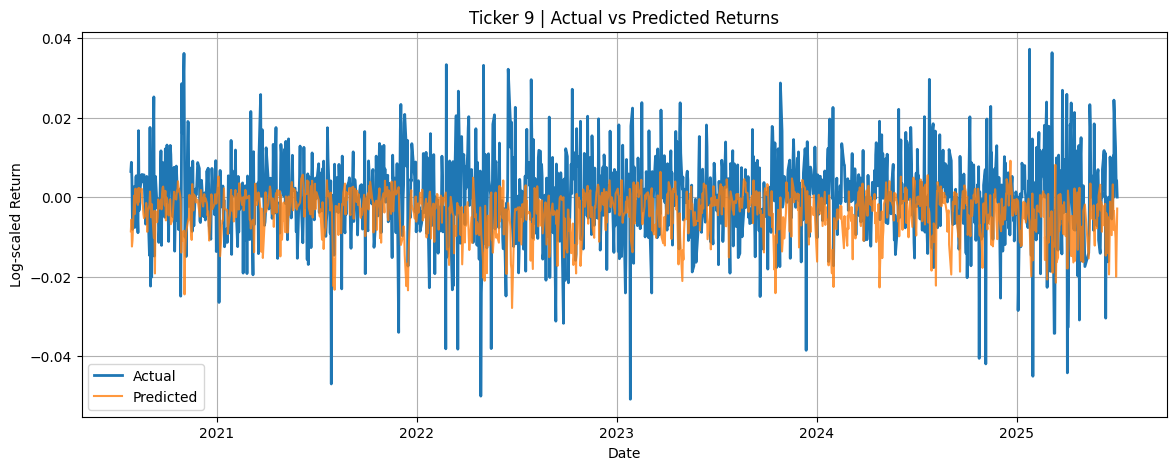

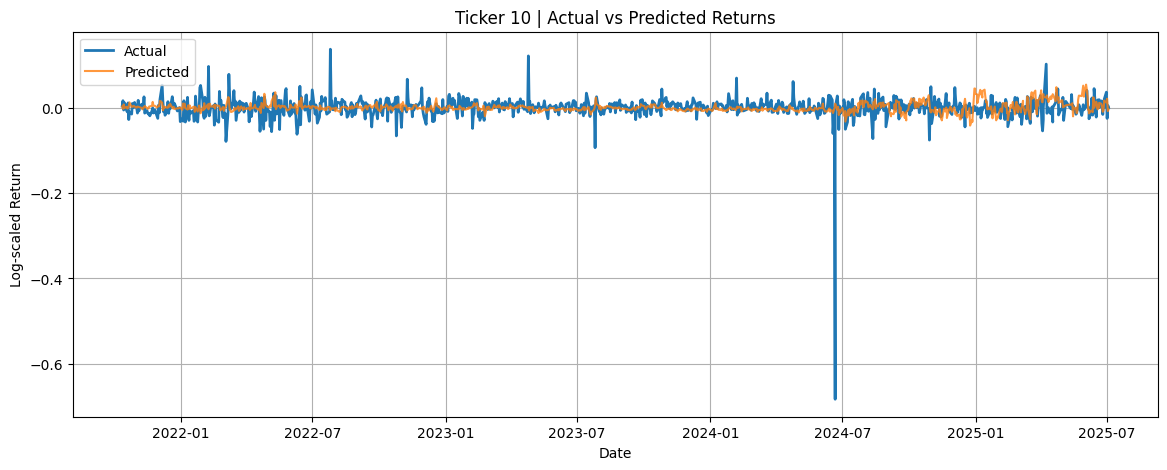

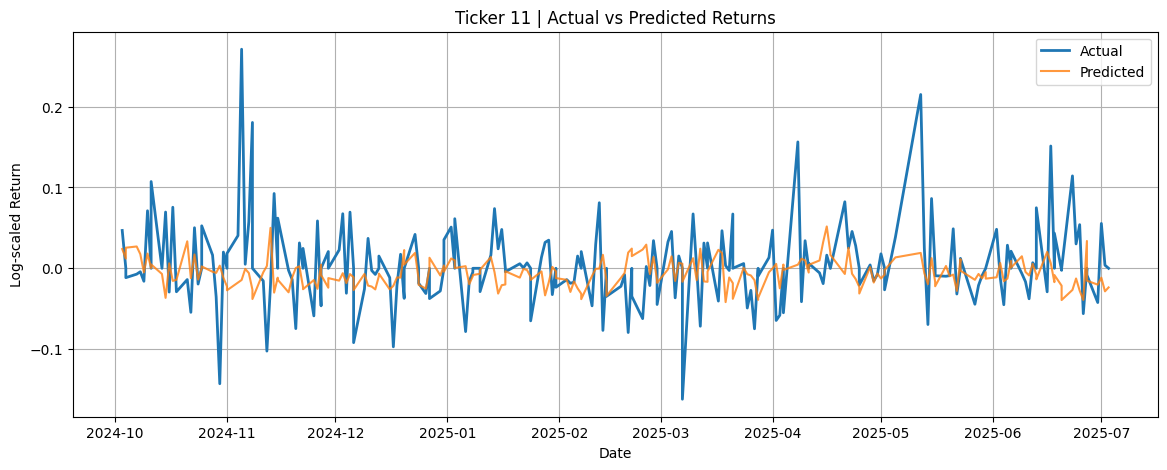

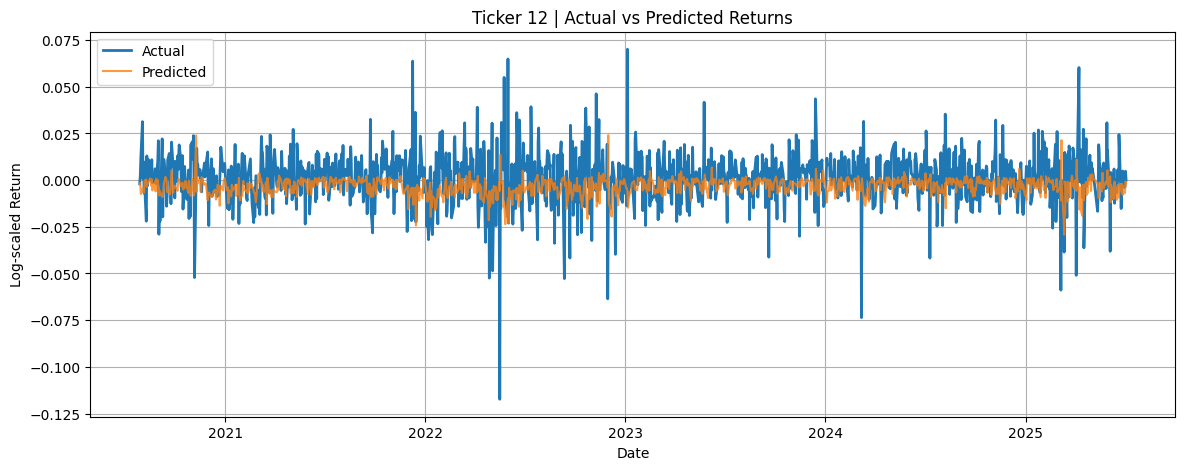

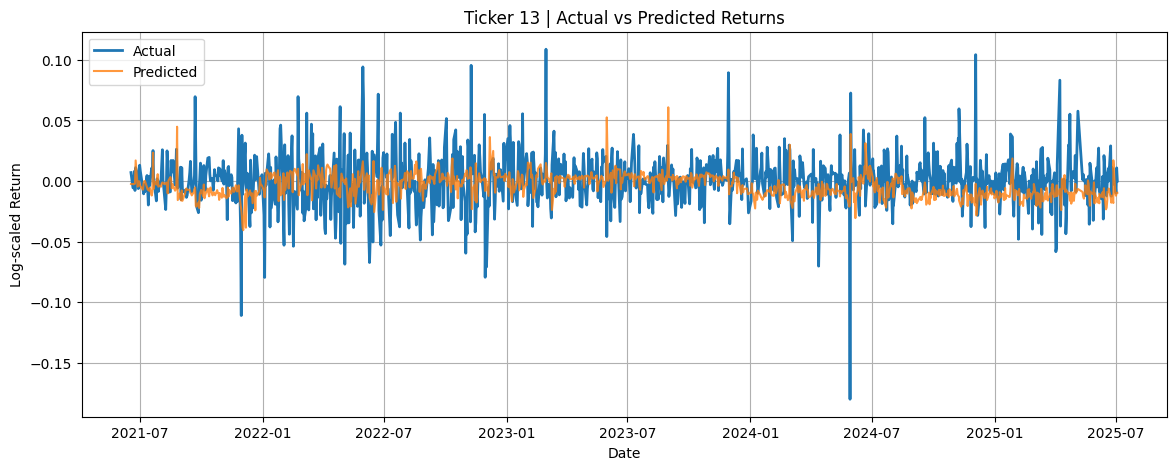

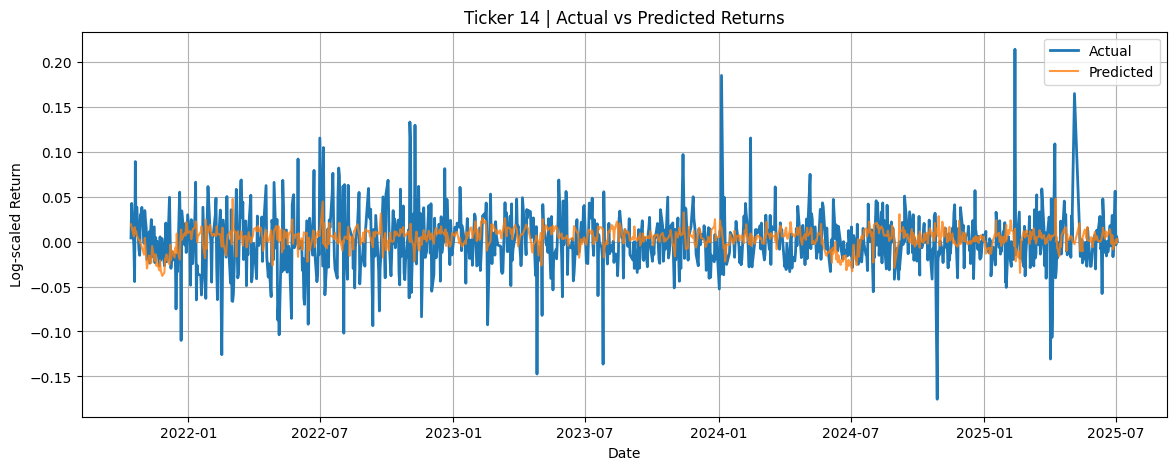

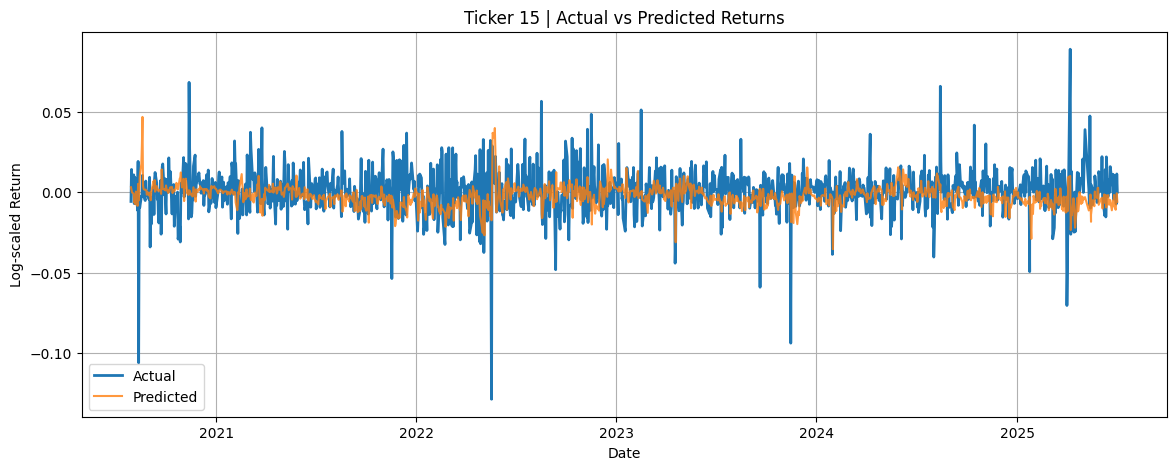

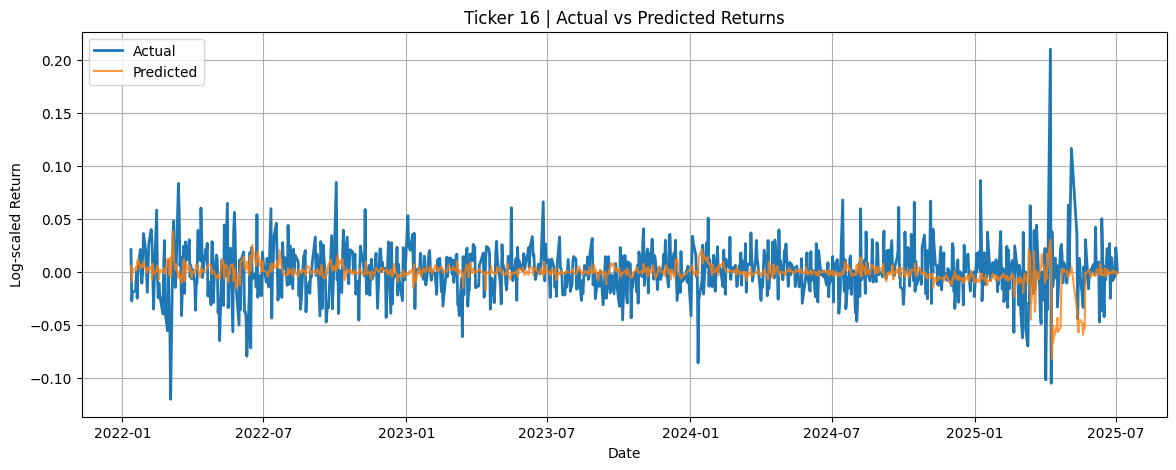

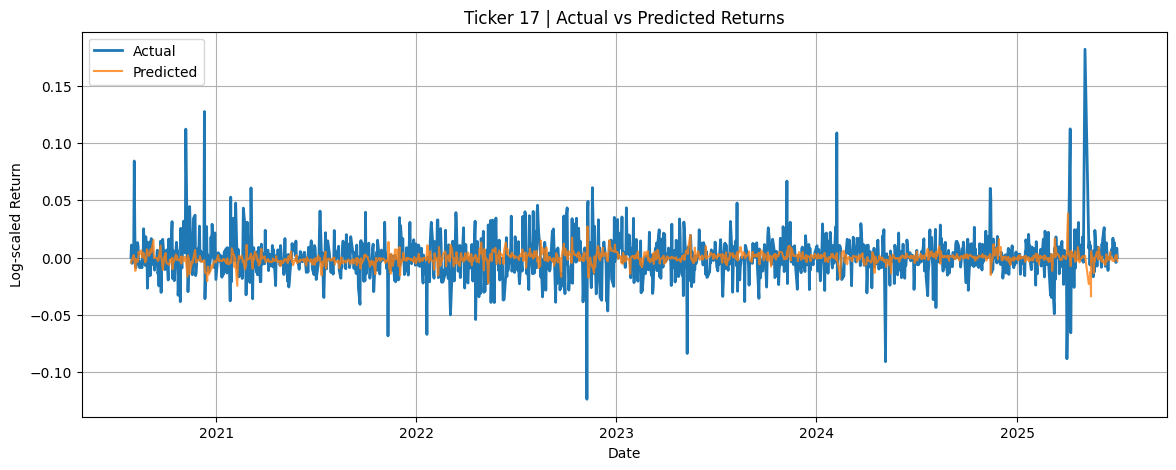

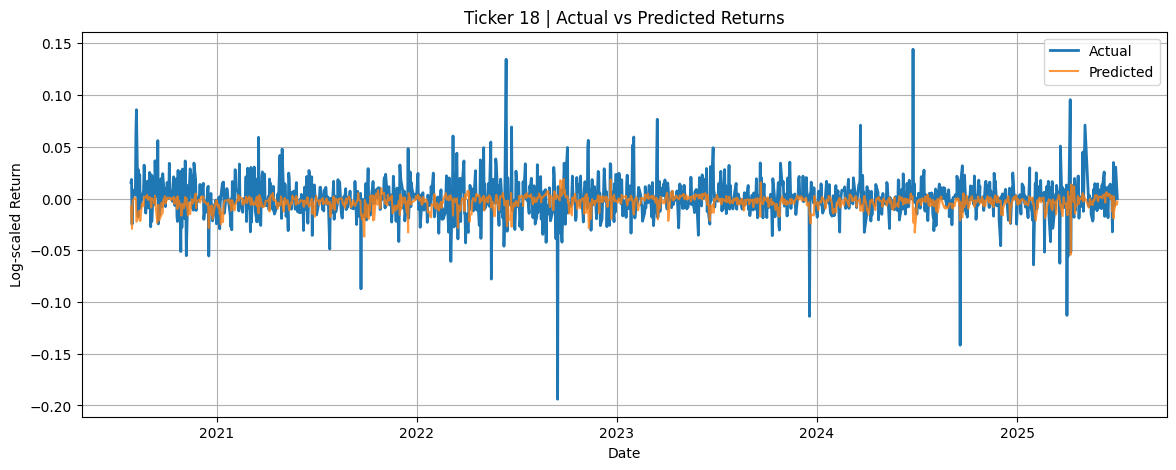

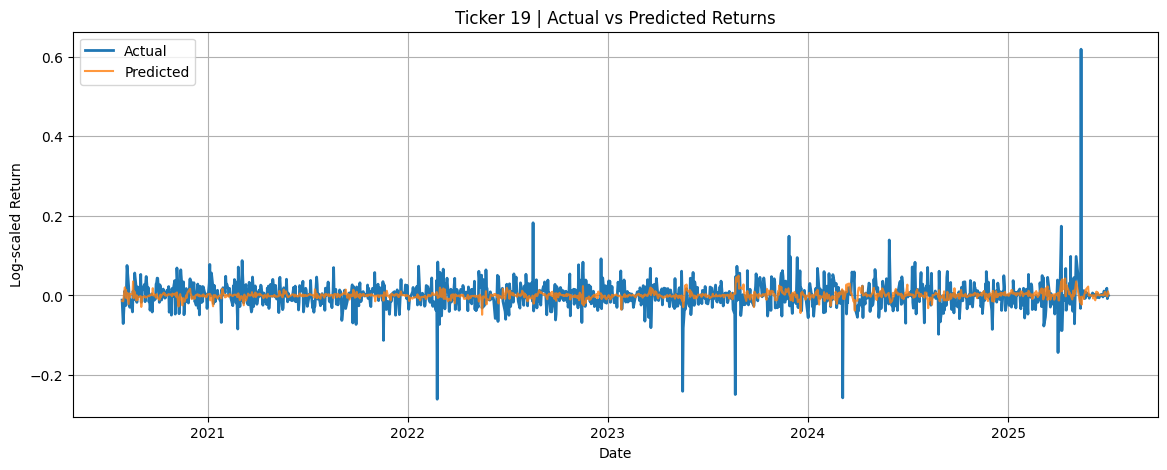

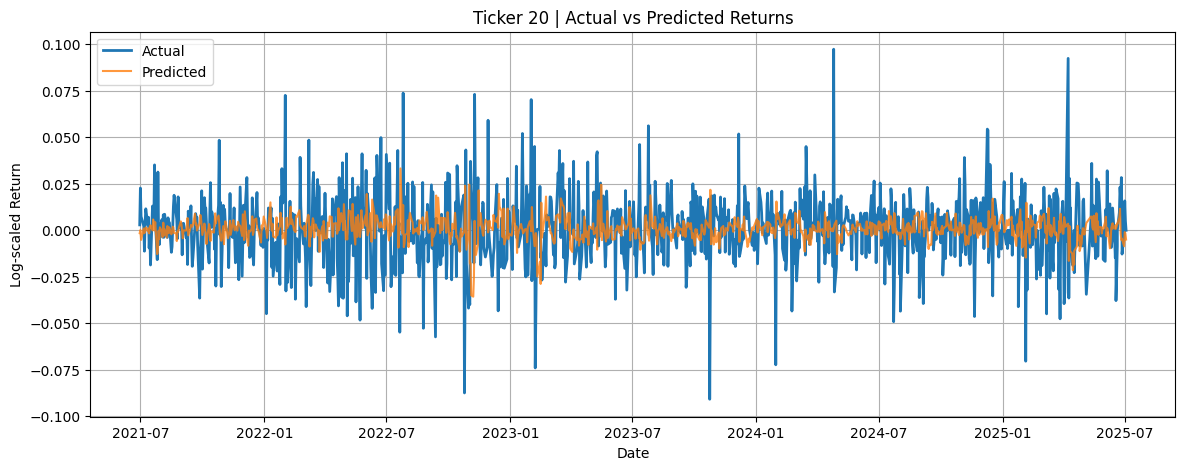

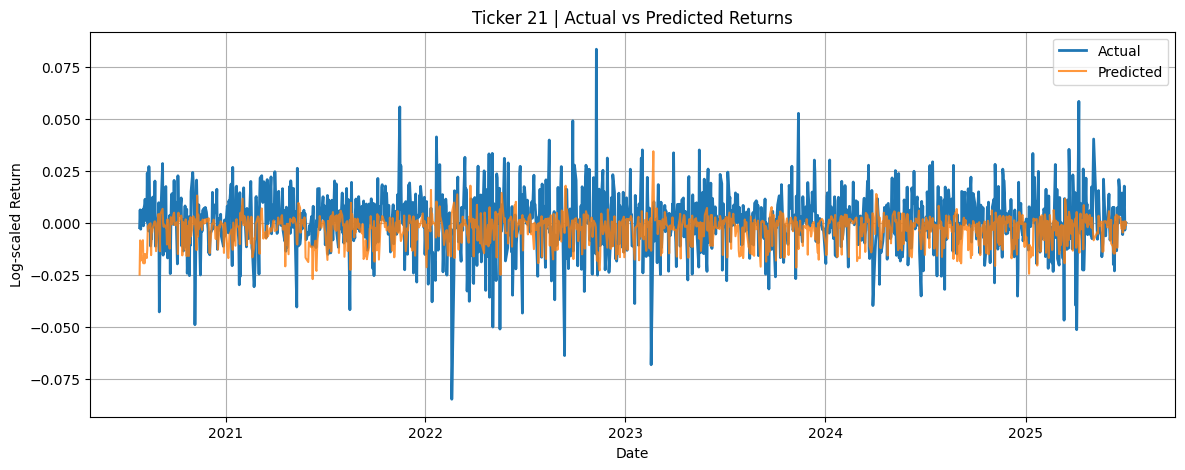

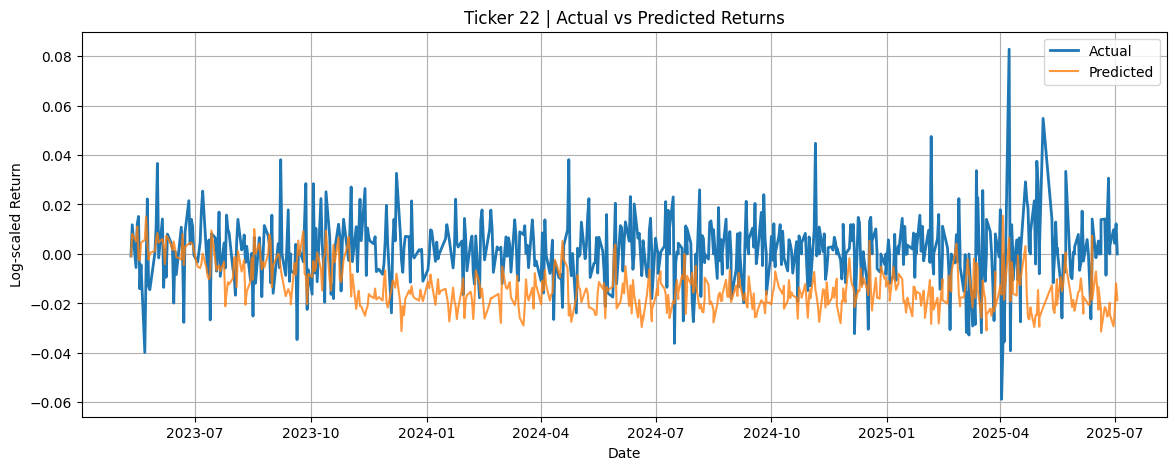

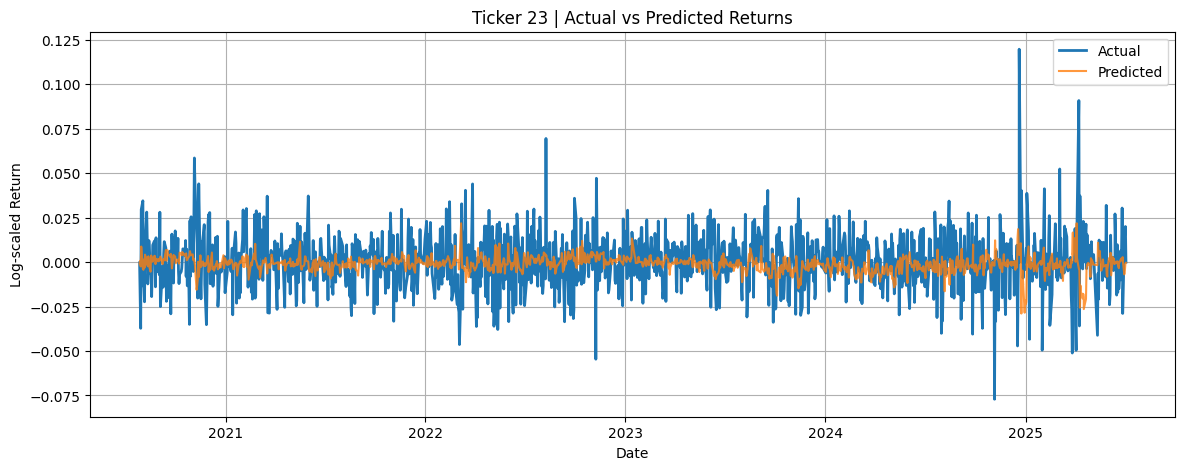

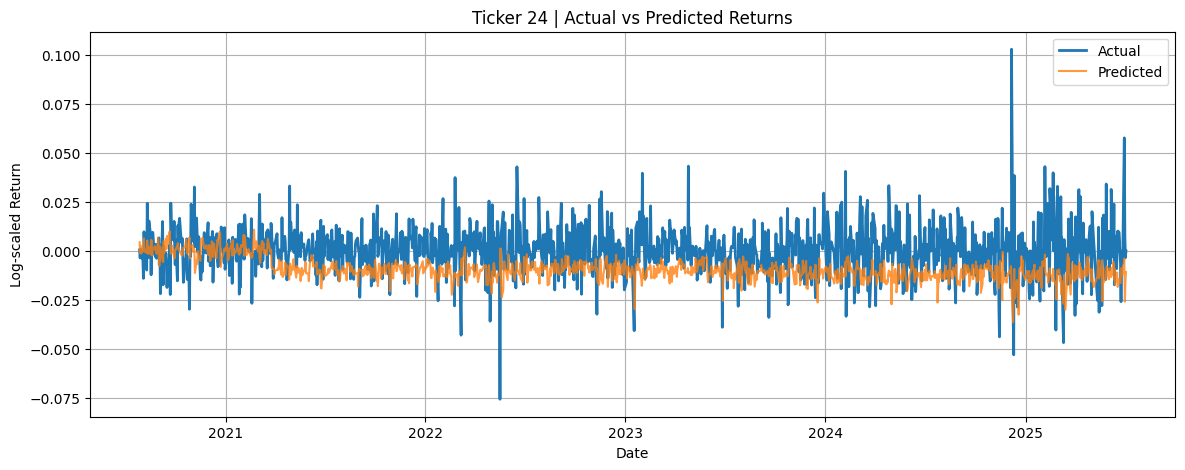

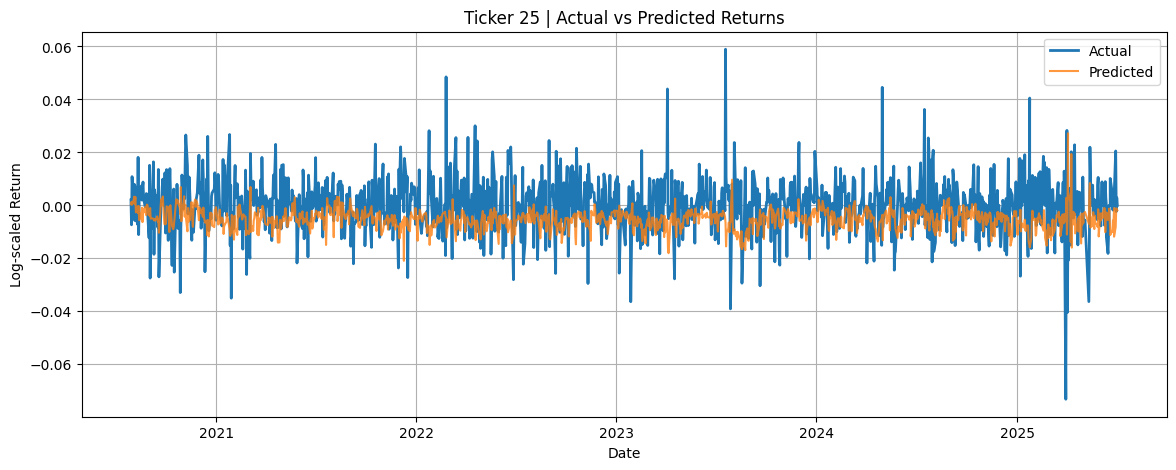

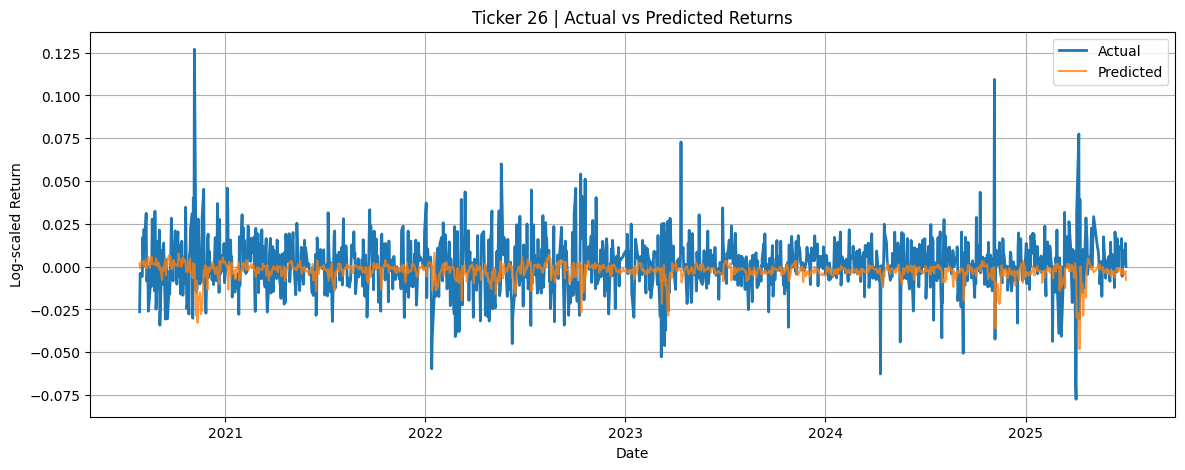

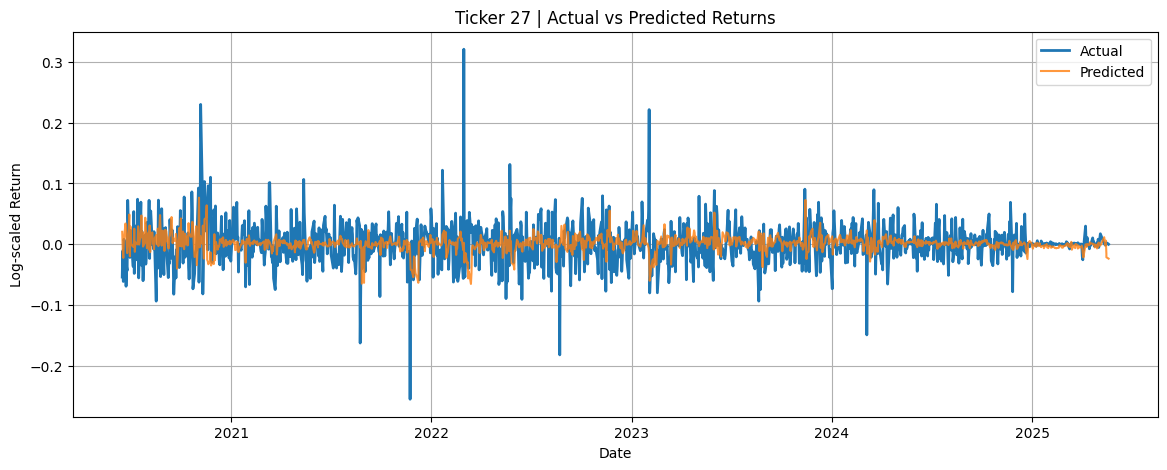

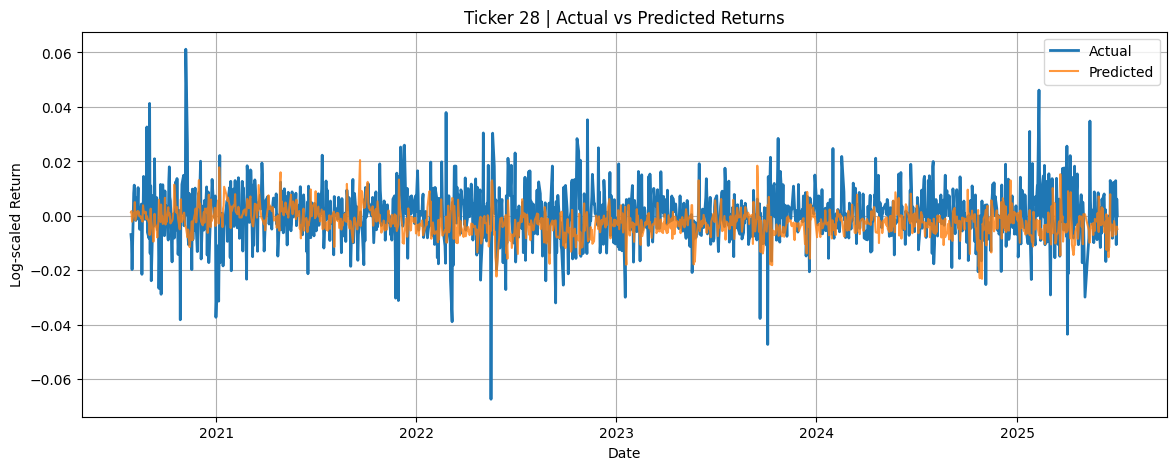

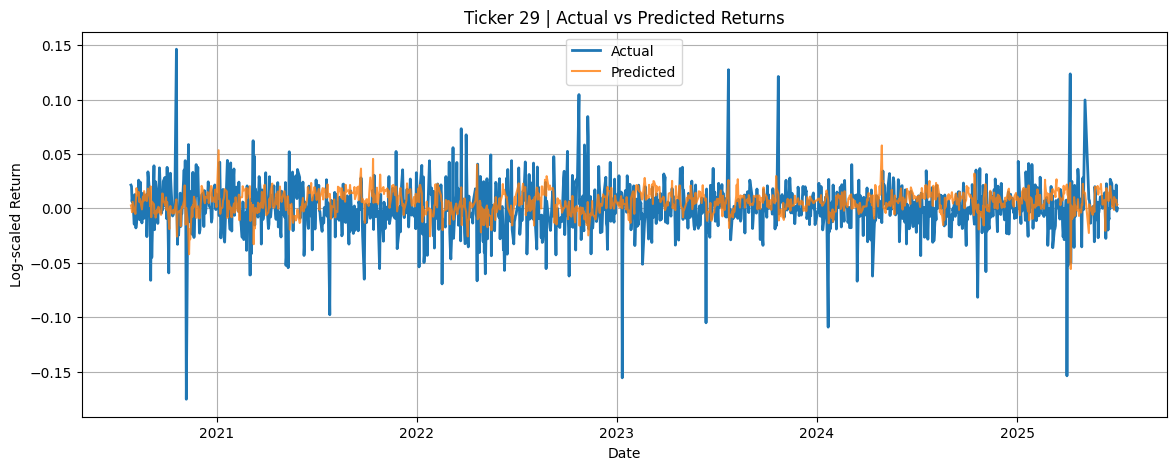

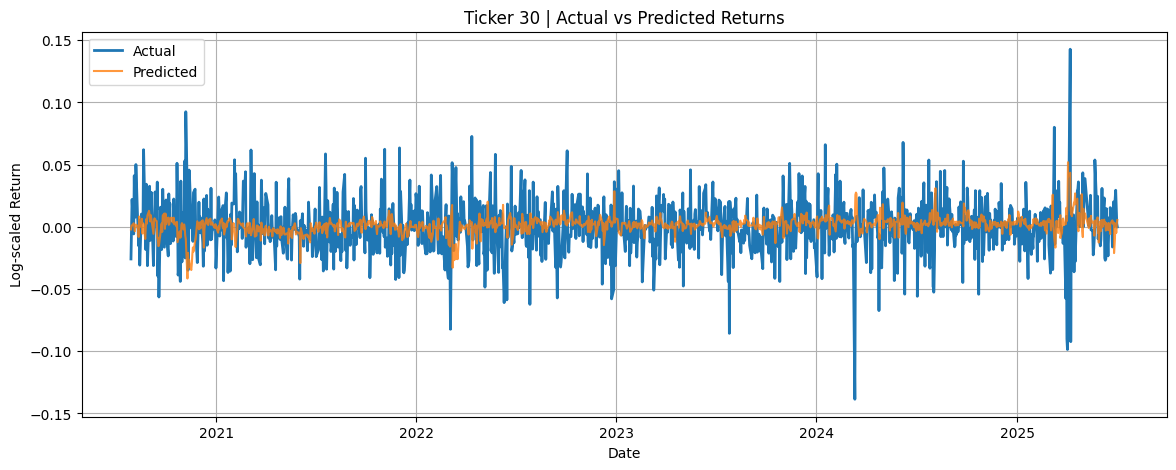

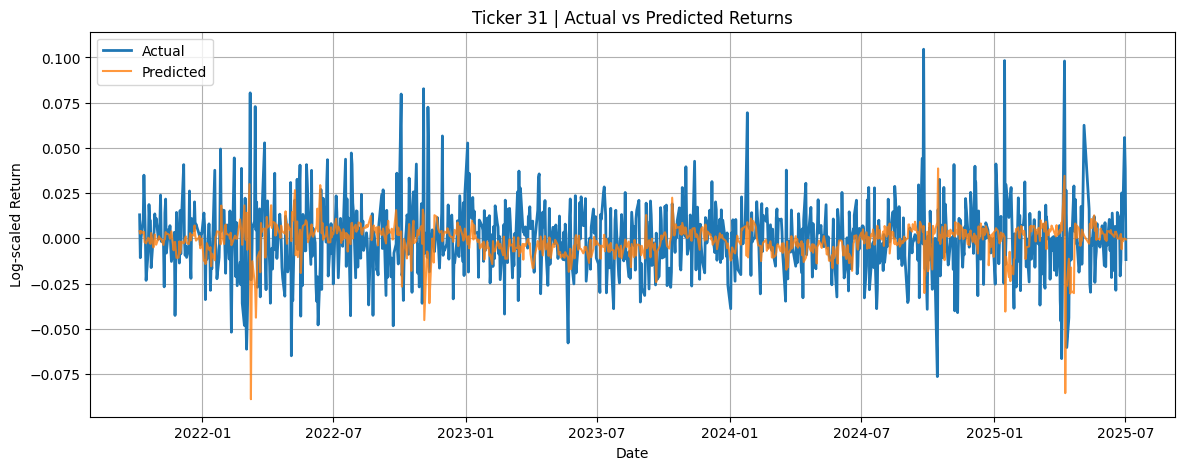

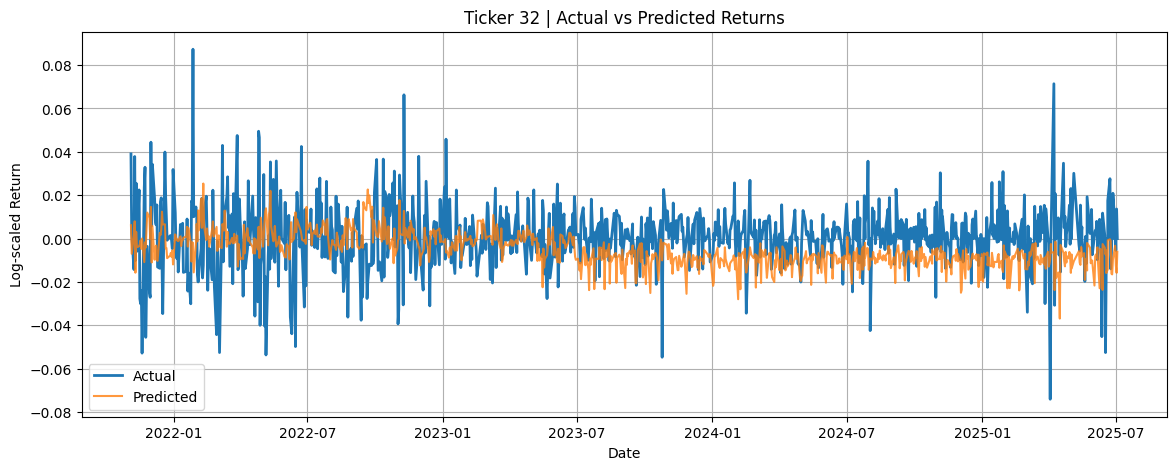

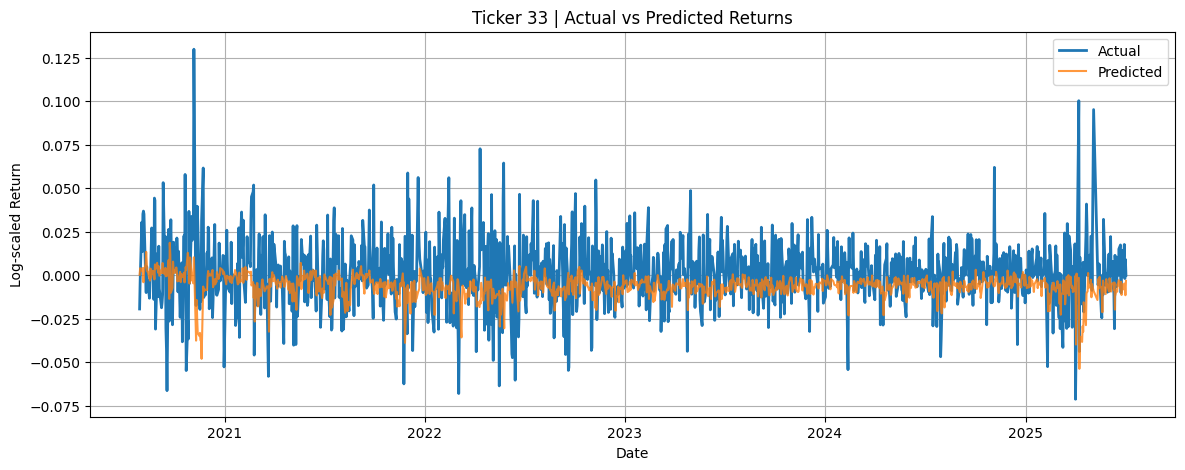

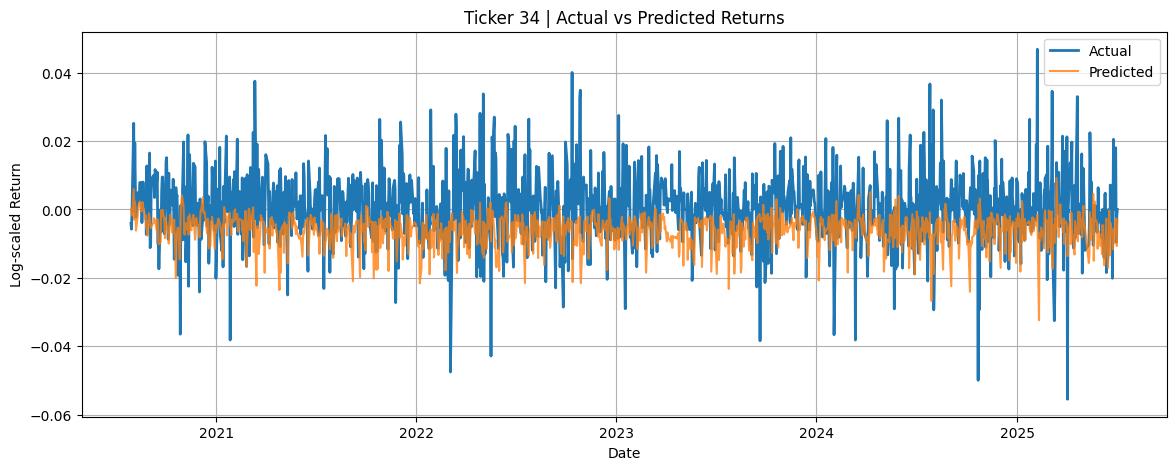

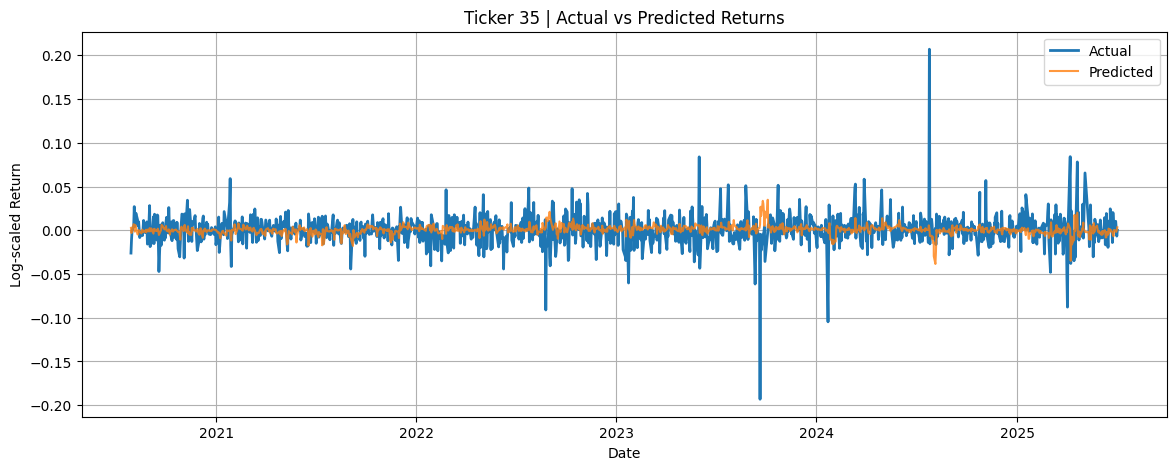

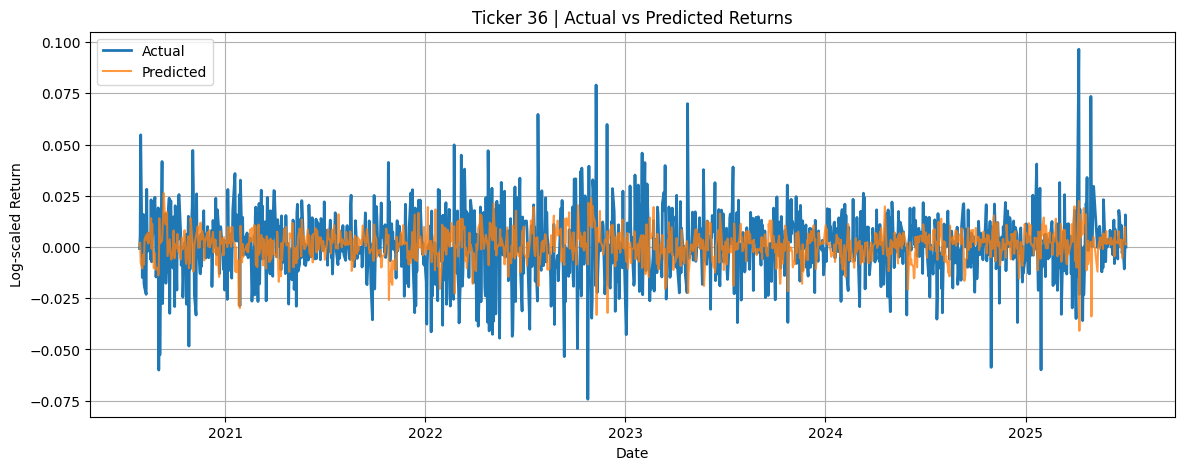

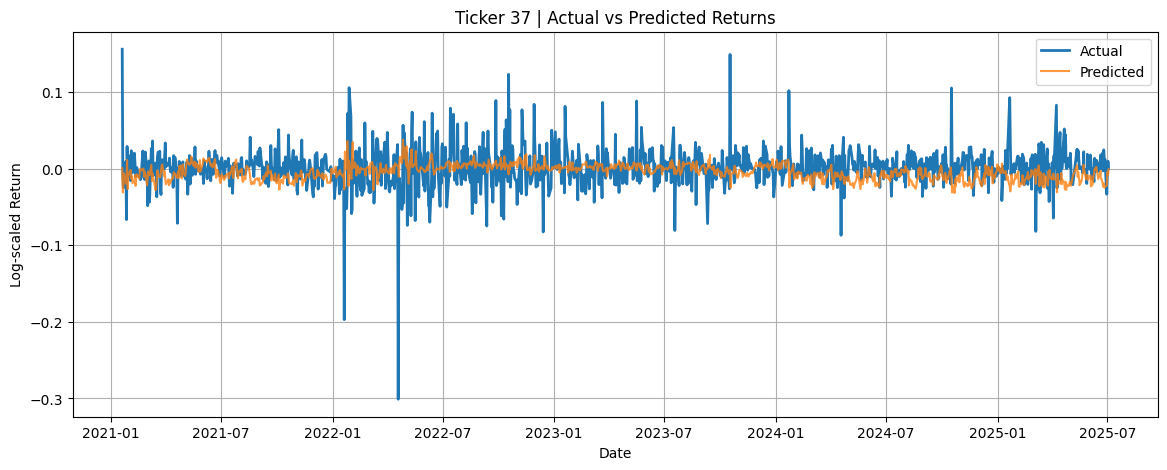

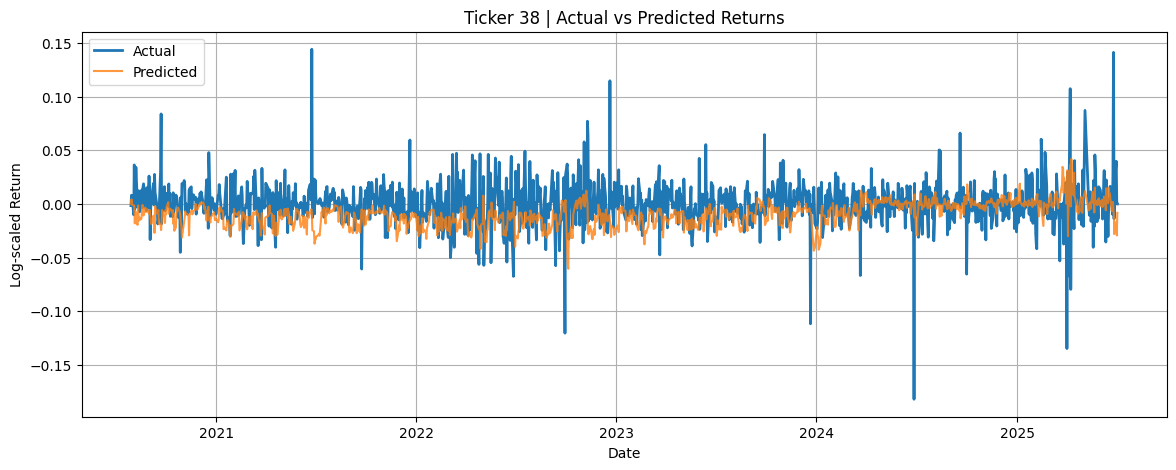

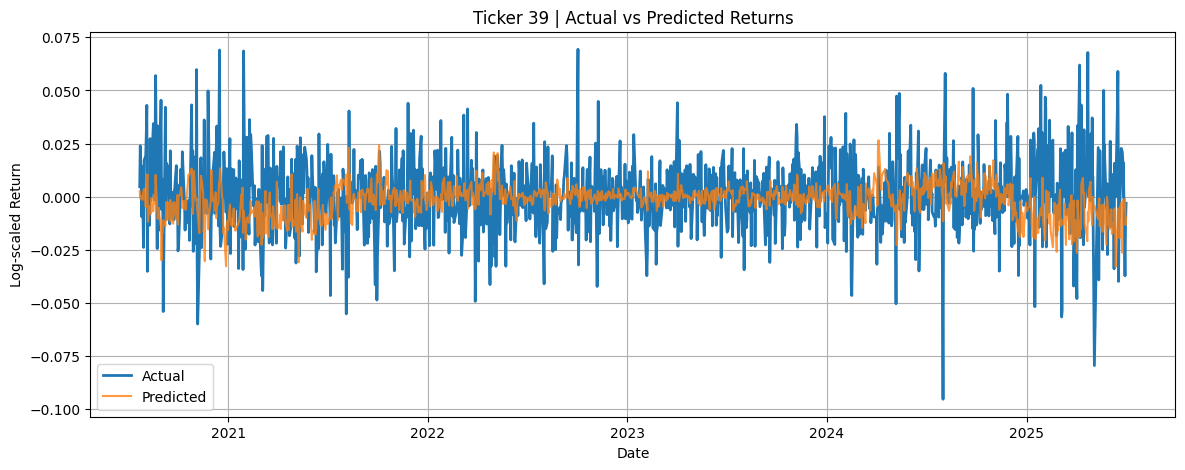

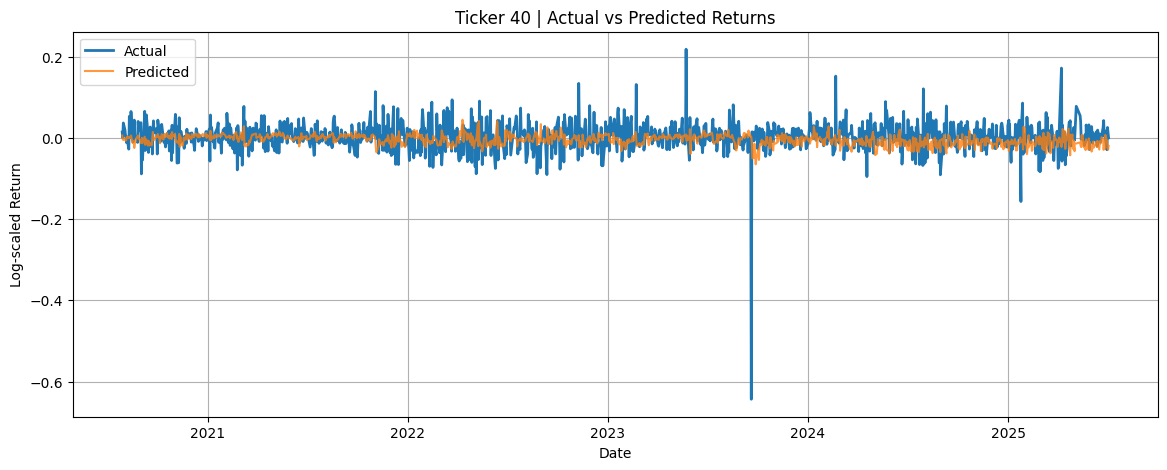

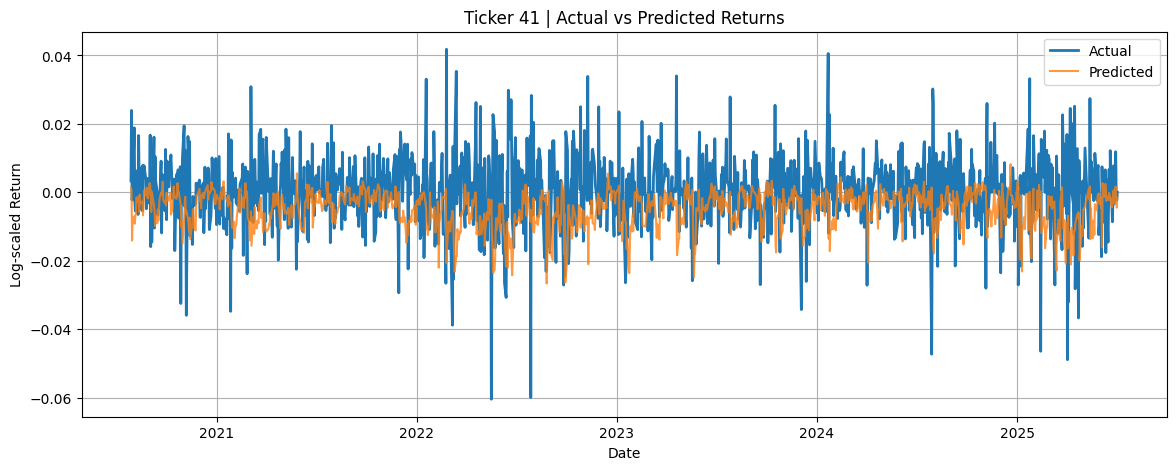

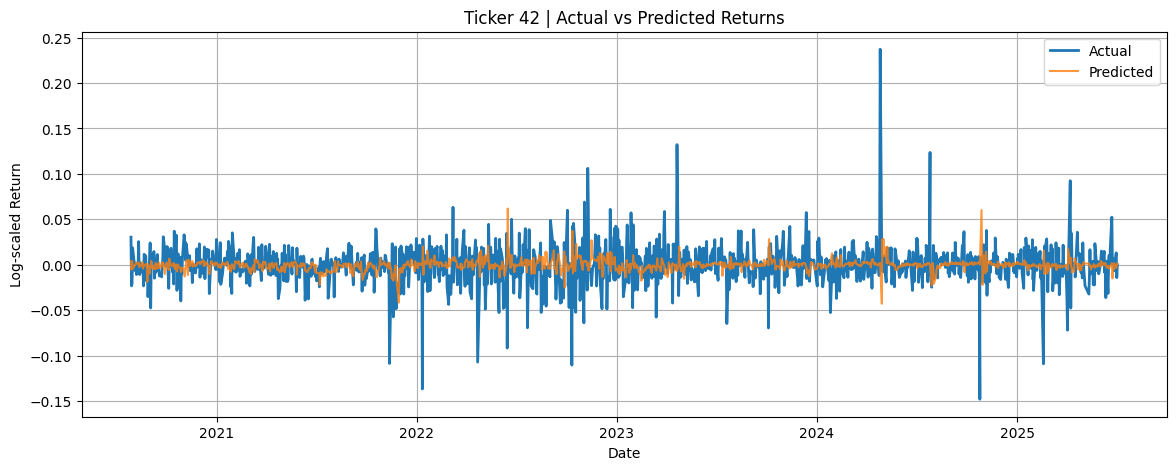

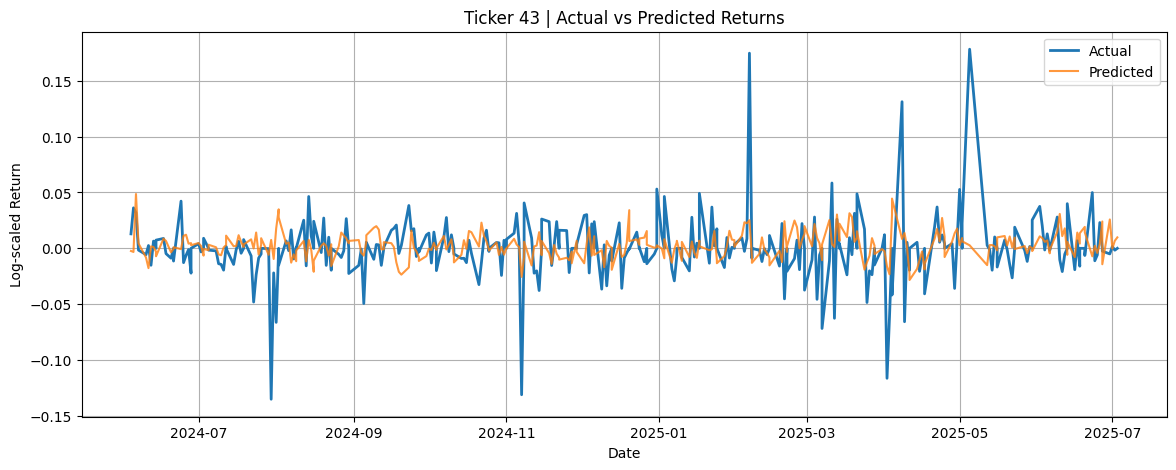

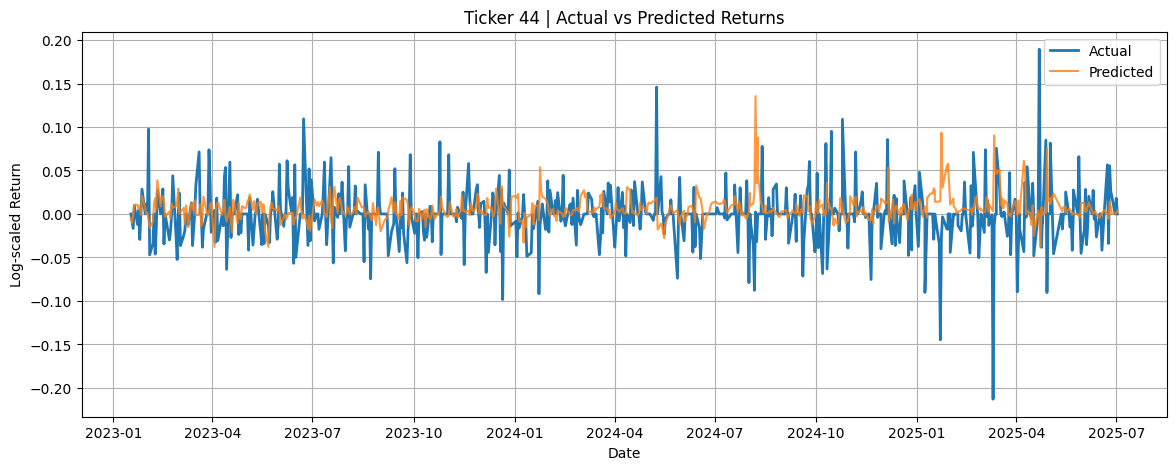

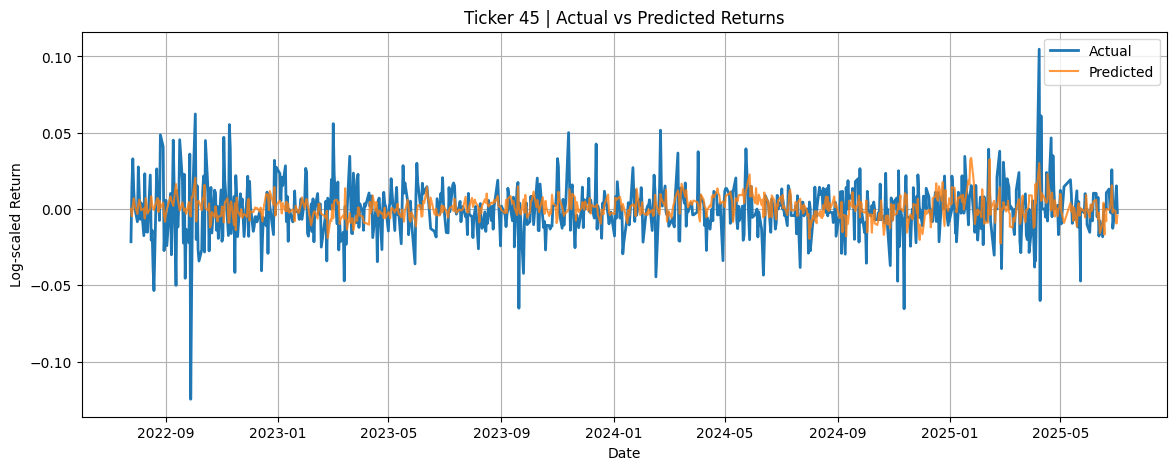

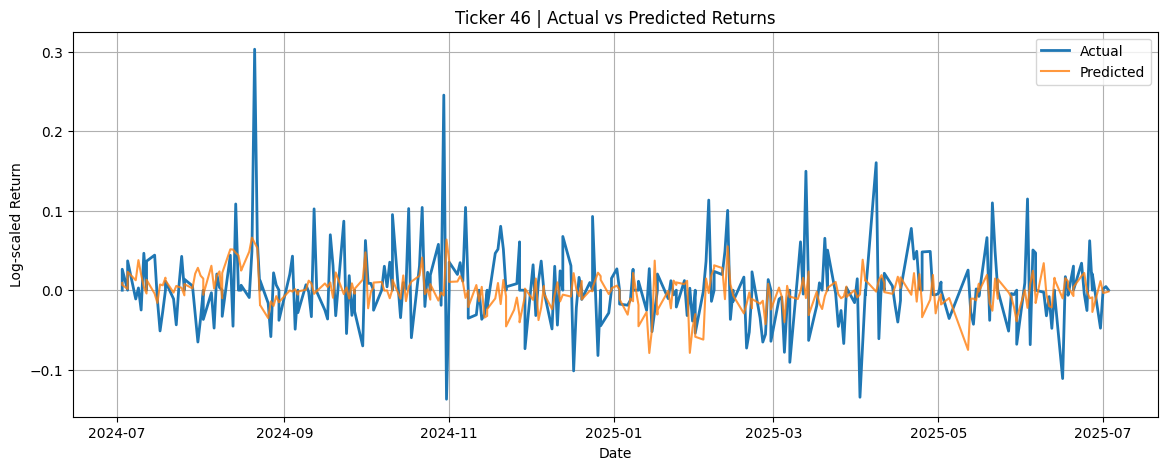

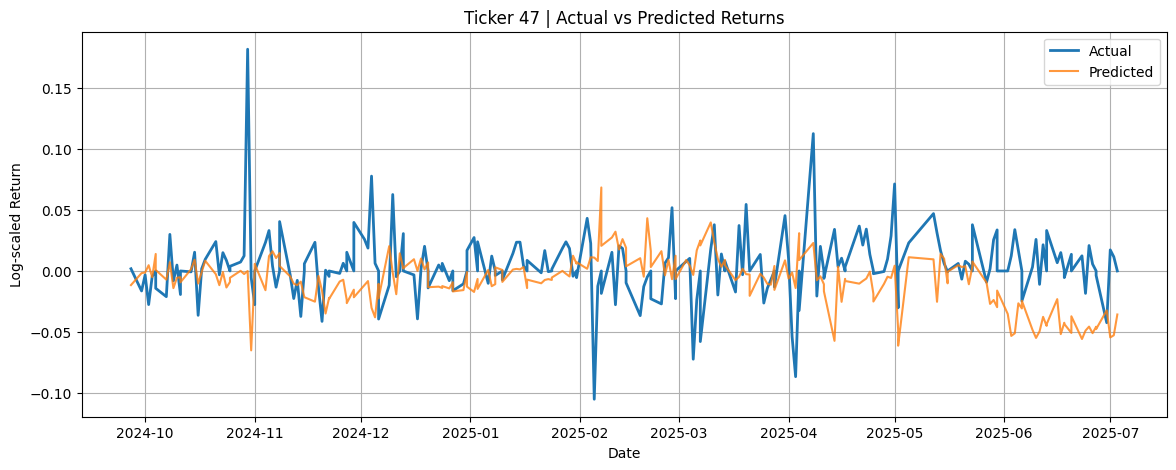

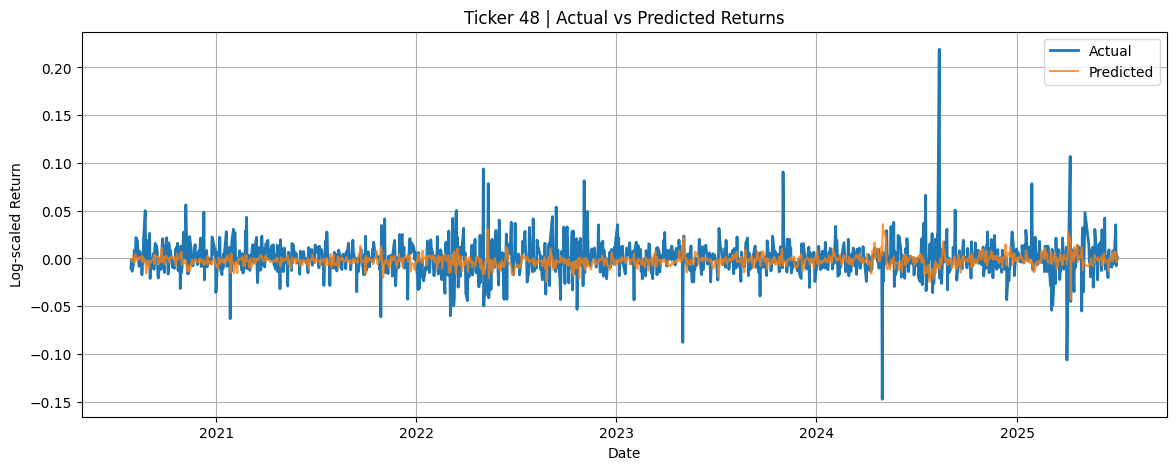

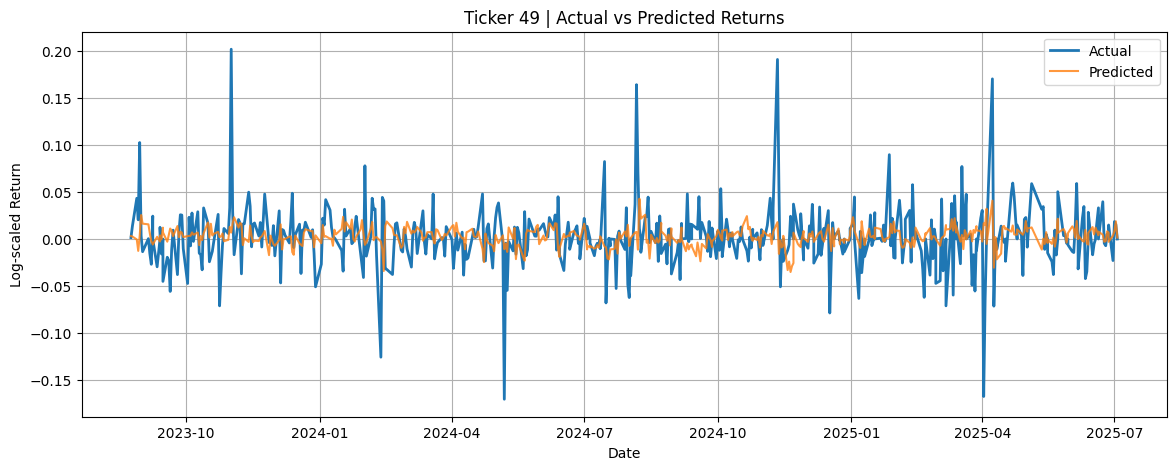

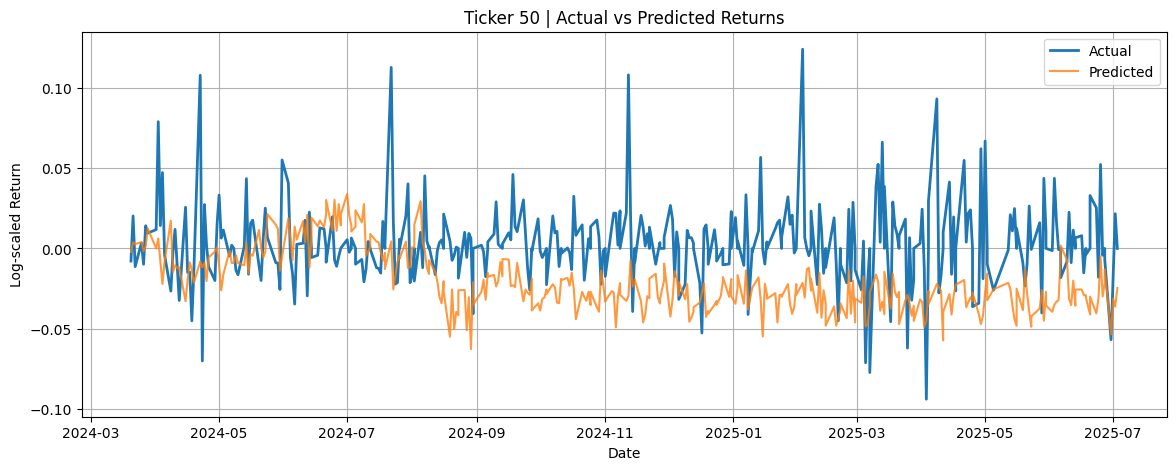

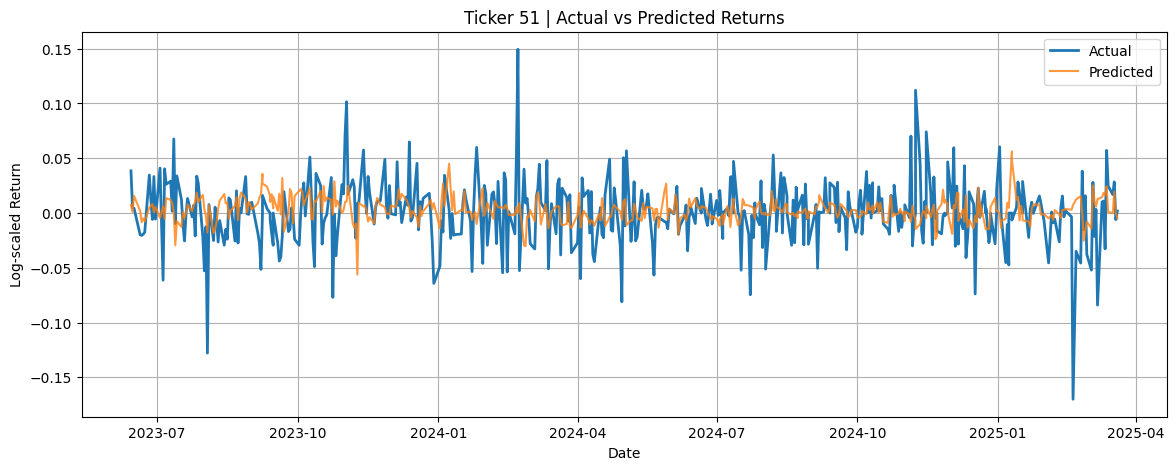

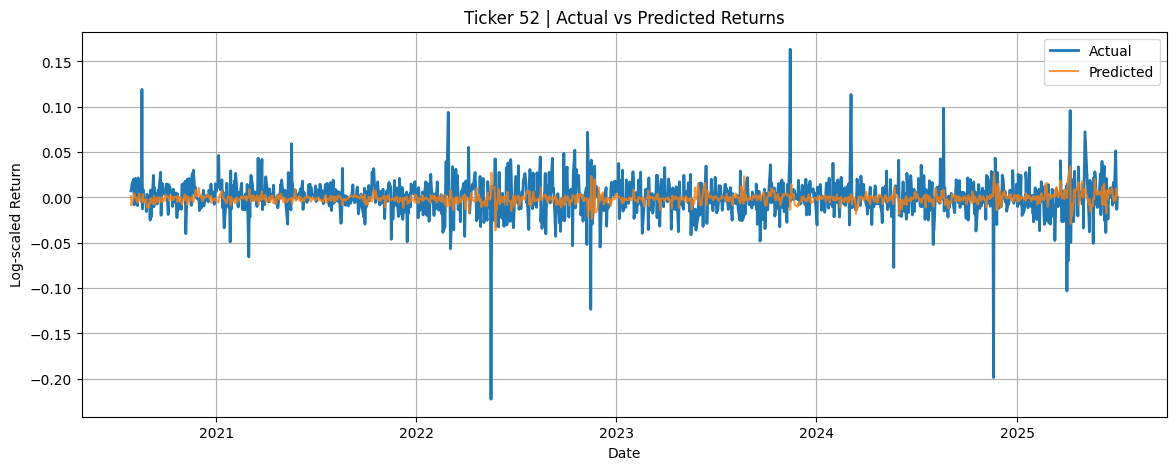

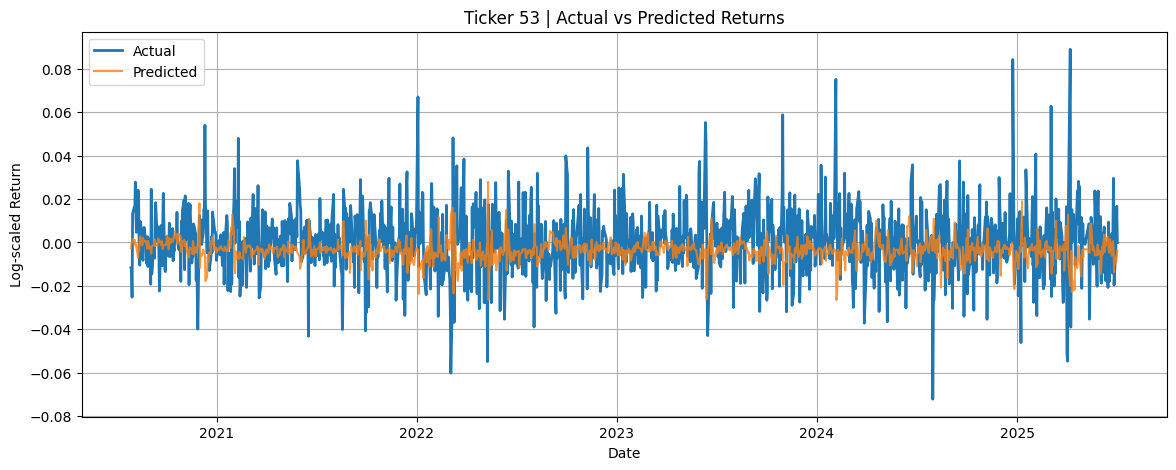

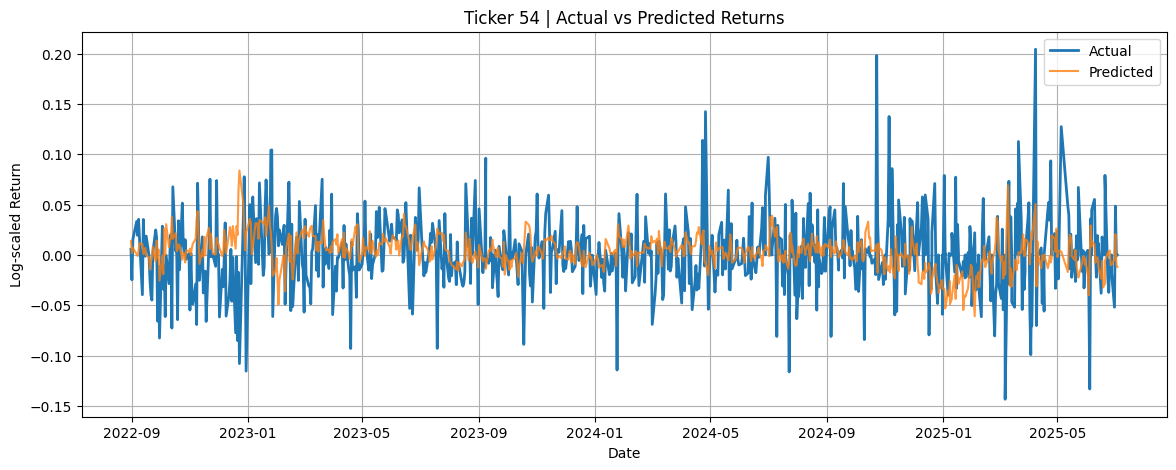

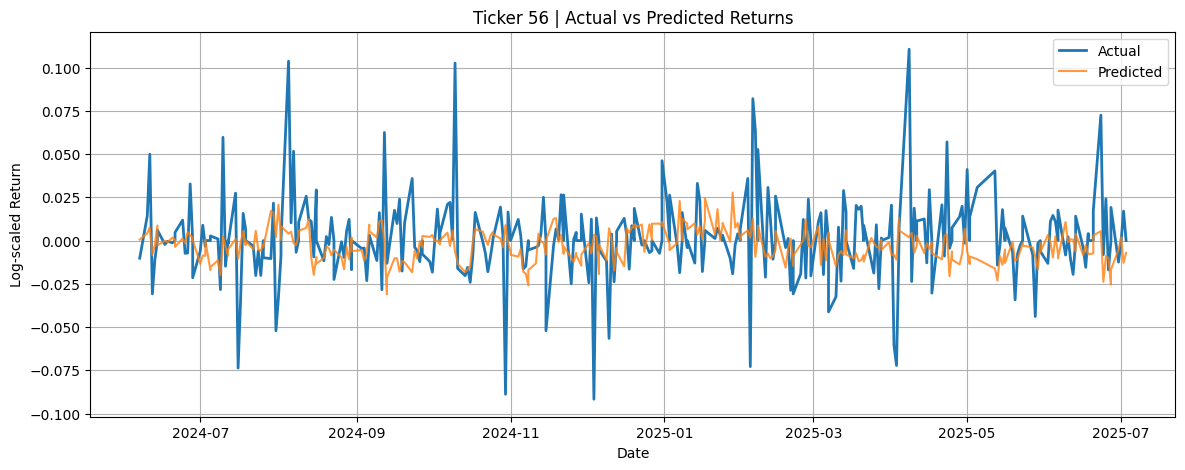

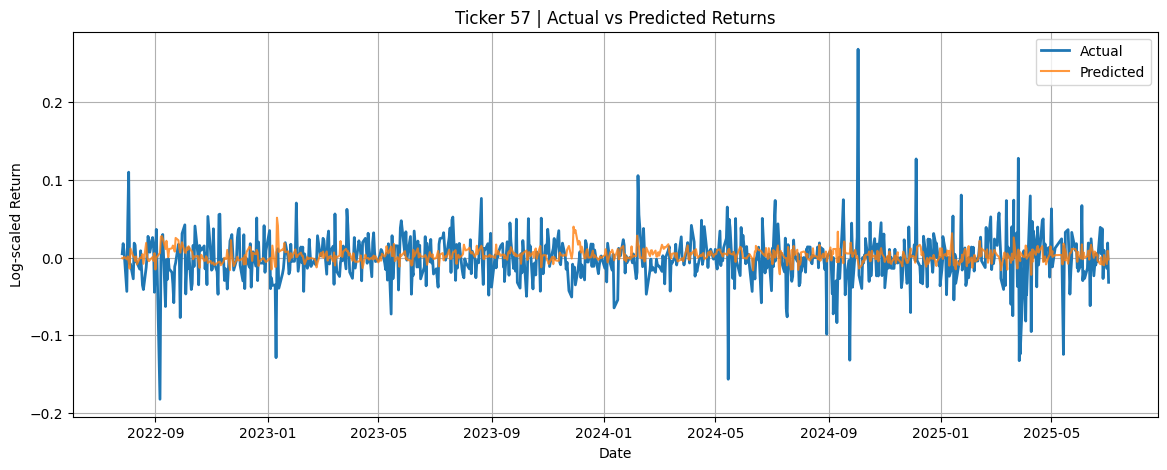

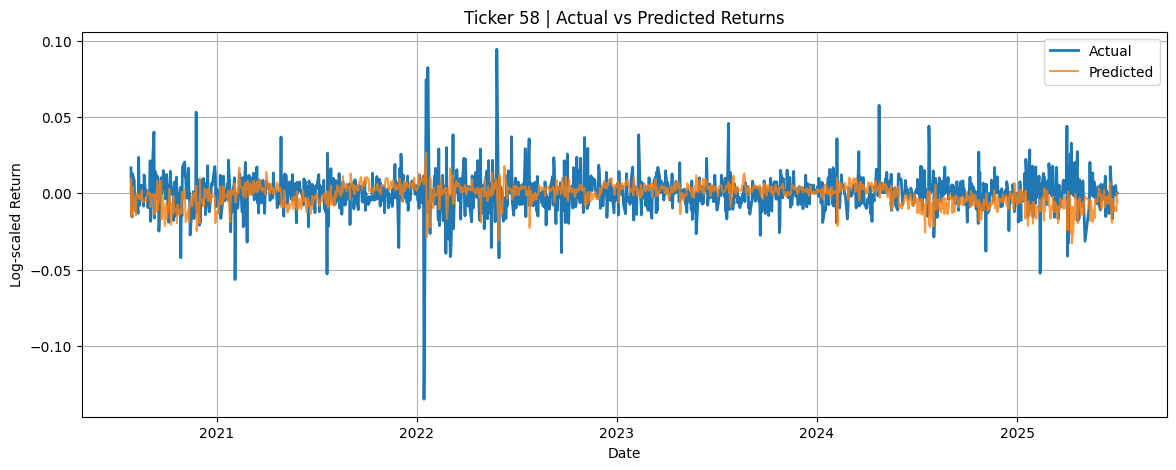

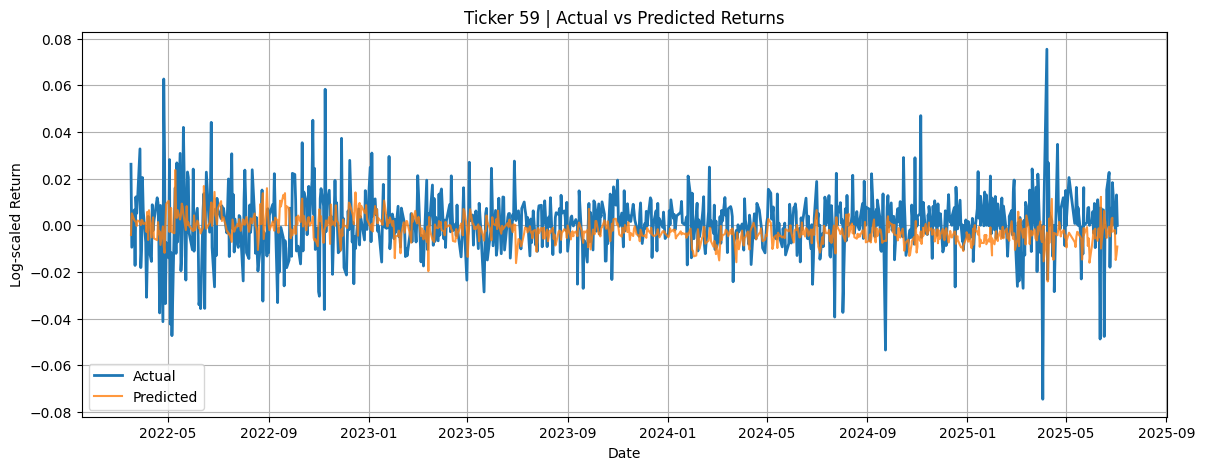

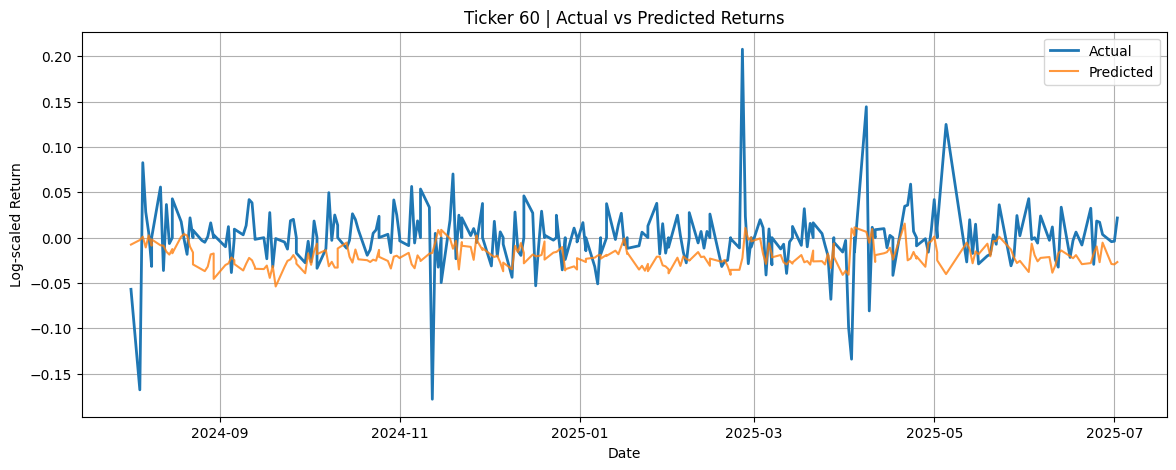

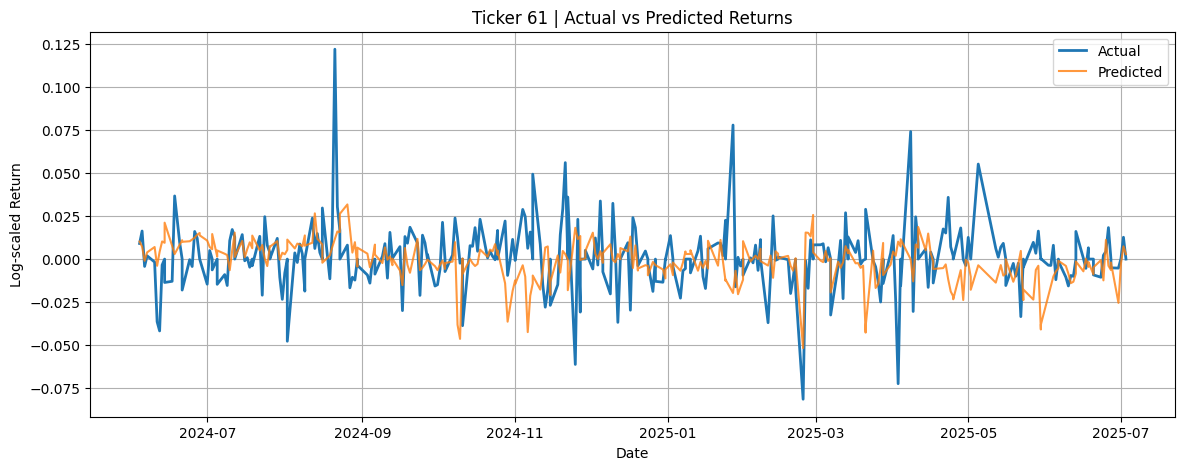

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =============================
# 1. LOAD & PREPROCESS
# =============================
df = pd.read_csv("/World-Stock-Prices-Dataset.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)
df = df.dropna(subset=["Open","High","Low","Close","Volume"])

for col in ["Open","High","Low","Close"]:
    df[col] = df[col].astype(float) / 100

for col in ["Ticker","Industry_Tag","Country"]:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# =============================
# 2. FEATURE ENGINEERING
# =============================
def create_features(group):
    group = group.copy()
    group["return_1d"] = group["Close"].pct_change()
    group["return_5d"] = group["Close"].pct_change(5)
    group["sma_10"] = group["Close"].rolling(10, min_periods=1).mean()
    group["sma_20"] = group["Close"].rolling(20, min_periods=1).mean()
    group["volatility_10"] = group["return_1d"].rolling(10, min_periods=1).std()
    group["target_return"] = group["Close"].pct_change().shift(-1)
    return group.dropna(subset=["target_return"])

df = df.groupby("Ticker", group_keys=False).apply(create_features)

df["target_return"] = np.sign(df["target_return"]) * np.log1p(np.abs(df["target_return"]))

features = [
    "Open","High","Low","Close","Volume",
    "return_1d","return_5d","sma_10","sma_20","volatility_10",
    "Industry_Tag","Country"
]

# =============================
# 3. TRAIN + STORE PREDICTIONS
# =============================
ticker_results = {}

for ticker, group in df.groupby("Ticker"):
    group = group.sort_values("Date")
    n = len(group)

    if n < 200:
        continue

    split = int(0.8 * n)
    train = group.iloc[:split]
    test  = group.iloc[split:]

    X_train = train[features]
    y_train = train["target_return"]
    X_test  = test[features]
    y_test  = test["target_return"]

    model = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",

        n_jobs=-1,
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    test = test.copy()
    test["Actual"] = y_test.values
    test["Predicted"] = preds

    ticker_results[ticker] = test[["Date","Actual","Predicted"]]

# =============================
# 4. TICKER-WISE PLOTS
# =============================
for ticker, data in ticker_results.items():
    plt.figure(figsize=(14,5))
    plt.plot(data["Date"], data["Actual"], label="Actual", linewidth=2)
    plt.plot(data["Date"], data["Predicted"], label="Predicted", alpha=0.8)
    plt.title(f"Ticker {ticker} | Actual vs Predicted Returns")
    plt.xlabel("Date")
    plt.ylabel("Log-scaled Return")
    plt.legend()
    plt.grid(True)
    plt.show()
